
=== Activity 1 — BSC Simulation ===
  Bits transmitted : 10,000
  Bit errors       : 999
  Simulated BER    : 0.0999
  Theoretical p    : 0.1000
  Match (±1%)      : YES

=== Activity 2 — Entropy at key points ===
  H(0.0) = 0.0000 bits/symbol
  H(0.1) = 0.4690 bits/symbol
  H(0.3) = 0.8813 bits/symbol
  H(0.5) = 1.0000 bits/symbol
  H(0.7) = 0.8813 bits/symbol
  H(0.9) = 0.4690 bits/symbol
  H(1.0) = 0.0000 bits/symbol

=== Activity 3 — Capacity at key points ===
  C(p=0.00) = 1.0000 bits/channel use
  C(p=0.05) = 0.7136 bits/channel use
  C(p=0.10) = 0.5310 bits/channel use
  C(p=0.20) = 0.2781 bits/channel use
  C(p=0.30) = 0.1187 bits/channel use
  C(p=0.50) = 0.0000 bits/channel use


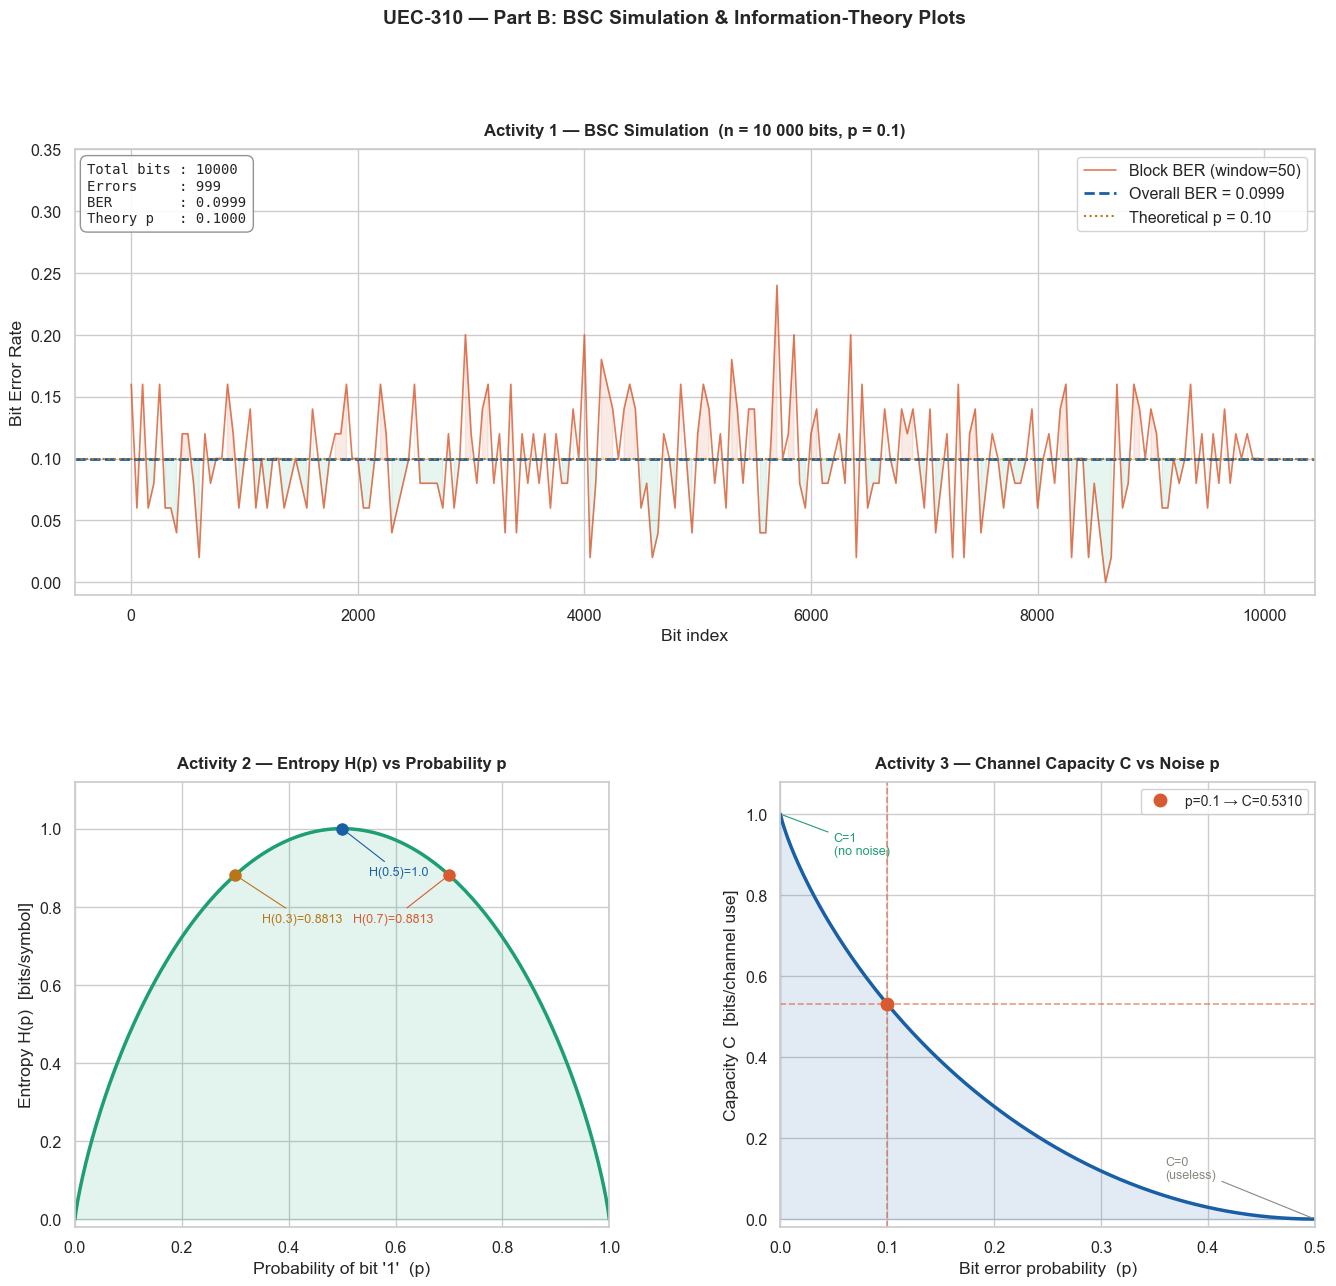

In [1]:
"""
UEC-310 Information and Communication Theory
ASSIGNMENT SCRIPT
BY : RISHIT BHANOT
Part B: Simulation-Based Tasks
Thapar Institute of Engineering and Technology
"""

# Recommended versions
# matplotlib >= 3.7
# seaborn >= 0.12
# numpy >= 1.24

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─────────────────────────────────────────────
# Global style configuration
# ─────────────────────────────────────────────
# Apply a clean plotting theme for all graphs in the figure.
sns.set_theme(style="whitegrid", font_scale=1.05)

# Define a consistent color palette used across all subplots.
BLUE   = "#185FA5"
CORAL  = "#D85A30"
TEAL   = "#1D9E75"
GRAY   = "#888780"
AMBER  = "#BA7517"

np.random.seed(42)

# ══════════════════════════════════════════════
# Activity 1: BSC Channel Simulation
# ══════════════════════════════════════════════

def bsc_simulation(n_bits=10_000, p_one=0.7, p_error=0.1):
    """Simulate transmission over a Binary Symmetric Channel."""

    # Generate the source bit stream:
    # bit '1' occurs with probability p_one
    # bit '0' occurs with probability (1 - p_one)
    source_bits = np.random.choice([0, 1], size=n_bits, p=[1 - p_one, p_one])

    # Create an error mask:
    # True means that bit position is flipped by the channel
    error_mask = np.random.rand(n_bits) < p_error

    # Apply XOR operation:
    # if error_mask is 1, the source bit flips
    # if error_mask is 0, the source bit remains unchanged
    received_bits = np.bitwise_xor(source_bits, error_mask.astype(int))

    # Count how many bits changed during transmission
    n_errors = np.sum(source_bits != received_bits)

    # Compute Bit Error Rate (BER)
    ber = n_errors / n_bits

    # Return all useful simulation outputs
    return source_bits, received_bits, error_mask, ber, n_errors

# ══════════════════════════════════════════════
# Activity 2: Entropy vs Probability
# ══════════════════════════════════════════════

def binary_entropy(p):
    """H(p) = -p*log2(p) - (1-p)*log2(1-p), safe at boundaries."""

    # Convert input into a NumPy array for element-wise operations
    p = np.asarray(p, dtype=float)

    # Start with all entropy values set to 0
    h = np.zeros_like(p)

    # Entropy formula is only valid directly for 0 < p < 1
    # At p = 0 or p = 1, entropy is defined as 0
    mask = (p > 0) & (p < 1)
    pm = p[mask]

    # Compute entropy only where the formula is valid
    h[mask] = -pm * np.log2(pm) - (1 - pm) * np.log2(1 - pm)

    return h

# ══════════════════════════════════════════════
# Activity 3: Channel Capacity vs Noise
# ══════════════════════════════════════════════

def bsc_capacity(p):
    """C = 1 - H(p)  for a BSC."""

    # For a Binary Symmetric Channel,
    # channel capacity is 1 minus the binary entropy
    return 1.0 - binary_entropy(p)

# ══════════════════════════════════════════════
# Run simulations and generate data
# ══════════════════════════════════════════════

# Perform the BSC simulation with default values
src, recv, errs, ber, n_err = bsc_simulation()

# Probability values for plotting entropy from 0 to 1
p_full  = np.linspace(0, 1, 500)

# Probability values for plotting BSC capacity from 0 to 0.5
# (capacity is symmetric beyond 0.5 for BSC noise interpretation)
p_half  = np.linspace(0, 0.5, 300)

# Compute entropy values over full probability range
H_full   = binary_entropy(p_full)

# Compute capacity values over channel error probability range
C_half   = bsc_capacity(p_half)

# ══════════════════════════════════════════════
# Figure layout — 3 panels
# ══════════════════════════════════════════════

# Create the main figure window
fig = plt.figure(figsize=(16, 14))

# Add a shared title for the complete figure
fig.suptitle(
    "UEC-310 — Part B: BSC Simulation & Information-Theory Plots",
    fontsize=14, fontweight="bold", y=0.98
)

# Use GridSpec to arrange 3 panels:
# top row = one wide plot
# bottom row = two side-by-side plots
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
ax1 = fig.add_subplot(gs[0, :])   # Activity 1 — full width
ax2 = fig.add_subplot(gs[1, 0])   # Activity 2
ax3 = fig.add_subplot(gs[1, 1])   # Activity 3

# ──────────────────────────────────────────────
# Panel 1 — BSC Bit Error Visualisation
# ──────────────────────────────────────────────

# Divide the transmitted bit stream into blocks of 50 bits
# and compute BER inside each block to observe local fluctuations
BLOCK = 50
n_bits = len(src)
n_blocks = n_bits // BLOCK

block_ber = np.array([
    np.mean(src[i*BLOCK:(i+1)*BLOCK] != recv[i*BLOCK:(i+1)*BLOCK])
    for i in range(n_blocks)
])

# Plot block-wise BER across the transmitted sequence
ax1.plot(
    np.arange(n_blocks) * BLOCK,
    block_ber,
    color=CORAL, linewidth=1.2, alpha=0.8, label=f"Block BER (window={BLOCK})"
)

# Add horizontal line for overall simulated BER
ax1.axhline(ber, color=BLUE, linewidth=2, linestyle="--",
            label=f"Overall BER = {ber:.4f}")

# Add horizontal line for theoretical channel error probability
ax1.axhline(0.1, color=AMBER, linewidth=1.5, linestyle=":",
            label="Theoretical p = 0.10")

# Highlight regions where local BER is above theoretical BER
ax1.fill_between(np.arange(n_blocks) * BLOCK, block_ber, 0.1,
                 where=(block_ber > 0.1), alpha=0.12, color=CORAL)

# Highlight regions where local BER is below or equal to theoretical BER
ax1.fill_between(np.arange(n_blocks) * BLOCK, block_ber, 0.1,
                 where=(block_ber <= 0.1), alpha=0.10, color=TEAL)

# Set title and labels for the first subplot
ax1.set_title("Activity 1 — BSC Simulation  (n = 10 000 bits, p = 0.1)",
              fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("Bit index")
ax1.set_ylabel("Bit Error Rate")
ax1.set_ylim(-0.01, 0.35)
ax1.legend(loc="upper right", framealpha=0.85)

# Prepare a text box summarizing simulation statistics
stats_txt = (
    f"Total bits : {10_000}\n"
    f"Errors     : {n_err}\n"
    f"BER        : {ber:.4f}\n"
    f"Theory p   : 0.1000"
)

# Display the summary statistics inside the plot
ax1.text(0.01, 0.97, stats_txt, transform=ax1.transAxes,
         fontsize=10, verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                   edgecolor=GRAY, alpha=0.9),
         fontfamily="monospace")

# ──────────────────────────────────────────────
# Panel 2 — Entropy vs Probability
# ──────────────────────────────────────────────

# Plot the binary entropy curve H(p)
ax2.plot(p_full, H_full, color=TEAL, linewidth=2.5)

# Fill area under the entropy curve for visual emphasis
ax2.fill_between(p_full, H_full, alpha=0.12, color=TEAL)

# Mark and annotate important probability points:
# p = 0.5 gives maximum entropy
# p = 0.7 and p = 0.3 are included as notable examples
for px, label, col in [
    (0.5, "H(0.5)=1.0", BLUE),
    (0.7, f"H(0.7)={binary_entropy(np.array([0.7]))[0]:.4f}", CORAL),
    (0.3, f"H(0.3)={binary_entropy(np.array([0.3]))[0]:.4f}", AMBER),
]:
    hy = binary_entropy(np.array([px]))[0]
    ax2.plot(px, hy, "o", color=col, markersize=8, zorder=5)
    ax2.annotate(label, xy=(px, hy),
                 xytext=(px + 0.05 if px < 0.7 else px - 0.18, hy - 0.12),
                 fontsize=9, color=col,
                 arrowprops=dict(arrowstyle="-", color=col, lw=0.8))

# Set title and axes labels for entropy plot
ax2.set_title("Activity 2 — Entropy H(p) vs Probability p",
              fontsize=12, fontweight="bold", pad=10)
ax2.set_xlabel("Probability of bit '1'  (p)")
ax2.set_ylabel("Entropy H(p)  [bits/symbol]")
ax2.set_xlim(0, 1)
ax2.set_ylim(-0.02, 1.12)

# ──────────────────────────────────────────────
# Panel 3 — Channel Capacity vs Noise
# ──────────────────────────────────────────────

# Plot BSC channel capacity as a function of bit error probability
ax3.plot(p_half, C_half, color=BLUE, linewidth=2.5)

# Fill area under the capacity curve
ax3.fill_between(p_half, C_half, alpha=0.12, color=BLUE)

# Mark the operating point at p = 0.1
c_op = bsc_capacity(np.array([0.1]))[0]
ax3.plot(0.1, c_op, "o", color=CORAL, markersize=9, zorder=5,
         label=f"p=0.1 → C={c_op:.4f}")

# Draw guide lines through the operating point
ax3.axvline(0.1, color=CORAL, linestyle="--", linewidth=1.2, alpha=0.6)
ax3.axhline(c_op, color=CORAL, linestyle="--", linewidth=1.2, alpha=0.6)

# Annotate the best-case and worst-case channel conditions
# p = 0   → perfect channel, maximum capacity
# p = 0.5 → completely random channel, zero capacity
ax3.annotate("C=1\n(no noise)", xy=(0, 1),
             xytext=(0.05, 0.90), fontsize=9, color=TEAL,
             arrowprops=dict(arrowstyle="-", color=TEAL, lw=0.8))
ax3.annotate("C=0\n(useless)", xy=(0.5, 0),
             xytext=(0.36, 0.10), fontsize=9, color=GRAY,
             arrowprops=dict(arrowstyle="-", color=GRAY, lw=0.8))

# Set title and axes labels for capacity plot
ax3.set_title("Activity 3 — Channel Capacity C vs Noise p",
              fontsize=12, fontweight="bold", pad=10)
ax3.set_xlabel("Bit error probability  (p)")
ax3.set_ylabel("Capacity C  [bits/channel use]")
ax3.set_xlim(0, 0.5)
ax3.set_ylim(-0.02, 1.08)
ax3.legend(loc="upper right", framealpha=0.85, fontsize=10)

# ══════════════════════════════════════════════
# Print summary results in console
# ══════════════════════════════════════════════

print("\n=== Activity 1 — BSC Simulation ===")
print(f"  Bits transmitted : 10,000")
print(f"  Bit errors       : {n_err}")
print(f"  Simulated BER    : {ber:.4f}")
print(f"  Theoretical p    : 0.1000")
print(f"  Match (±1%)      : {'YES' if abs(ber - 0.1) < 0.01 else 'NO'}")

print("\n=== Activity 2 — Entropy at key points ===")
for px in [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]:
    print(f"  H({px:.1f}) = {binary_entropy(np.array([px]))[0]:.4f} bits/symbol")

print("\n=== Activity 3 — Capacity at key points ===")
for px in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]:
    print(f"  C(p={px:.2f}) = {bsc_capacity(np.array([px]))[0]:.4f} bits/channel use")